# Apriori

## Importing the libraries

In [76]:
!pip install apyori

In [77]:
# For numerical operations and arrays
import numpy as np

# For plotting graphs and visualizations
import matplotlib.pyplot as plt

# For data manipulation and analysis using DataFrames
import pandas as pd

## Data Preprocessing

In [78]:
# Load the dataset from the CSV file without headers
dataset = pd.read_csv('Market_Basket_Optimisation.csv', header=None)

# Initialize an empty list to store all transactions
transactions = []

# Loop through each row in the dataset (each transaction)
for i in range(0, 7501):
    # For each row, create a list of all items (columns), convert to string, and ignore 'nan'
    transactions.append([str(dataset.values[i,j])
                         for j in range(0, 20)
                         if str(dataset.values[i,j]) != 'nan'])

In [79]:
# Print each transaction on a separate line
for i, transaction in enumerate(transactions):
    print(f"Transaction {i+1}: {transaction}")

Transaction 1: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
Transaction 2: ['burgers', 'meatballs', 'eggs']
Transaction 3: ['chutney']
Transaction 4: ['turkey', 'avocado']
Transaction 5: ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']
Transaction 6: ['low fat yogurt']
Transaction 7: ['whole wheat pasta', 'french fries']
Transaction 8: ['soup', 'light cream', 'shallot']
Transaction 9: ['frozen vegetables', 'spaghetti', 'green tea']
Transaction 10: ['french fries']
Transaction 11: ['eggs', 'pet food']
Transaction 12: ['cookies']
Transaction 13: ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil']
Transaction 14: ['spaghetti', 'champagne', 'cookies']
Transaction 15: ['mineral water', 'salmon']
Transaction 16: ['mineral 

## Training the Apriori model on the dataset

In [80]:
# Import the apriori function from the apyori library
from apyori import apriori

# Apply the Apriori algorithm on the transactions
# min_support = 0.003 -> itemsets must appear in at least 0.3% of all transactions
# min_confidence = 0.2 -> rules must have at least 20% confidence
# min_lift = 3 -> rules must have a lift of at least 3 (strong association)
# min_length = 2 -> consider itemsets with at least 2 items
# max_length = 2 -> consider itemsets with at most 2 items
rules = apriori(transactions=transactions,
                min_support=0.003,
                min_confidence=0.2,
                min_lift=3,
                min_length=2,
                max_length=2)

## Visualising the results

### Displaying the first results coming directly from the output of the apriori function

In [81]:
# Convert the rules generator object into a list
# This allows us to access and visualize the Apriori output directly
results = list(rules)

In [82]:
results

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)]),
 RelationRecord(items=frozenset({'mushroom cream sauce', 'escalope'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]),
 RelationRecord(items=frozenset({'pasta', 'escalope'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]),
 RelationRecord(items=frozenset({'fromage blanc', 'honey'}), support=0.003332888948140248, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confidence=0

### Putting the results well organised into a Pandas DataFrame

In [83]:
# Define a function to extract important fields from Apriori results
def inspect(results):
    # Extract the first item from the Left Hand Side of the rule
    lhs         = [tuple(result[2][0][0])[0] for result in results]

    # Extract the first item from the Right Hand Side of the rule
    rhs         = [tuple(result[2][0][1])[0] for result in results]

    # Extract support value for each rule
    supports    = [result[1] for result in results]

    # Extract confidence value for each rule
    confidences = [result[2][0][2] for result in results]

    # Extract lift value for each rule
    lifts       = [result[2][0][3] for result in results]

    # Combine all extracted fields into a list of tuples
    return list(zip(lhs, rhs, supports, confidences, lifts))

# Apply the inspect function and create a Pandas DataFrame with proper column names
resultsinDataFrame = pd.DataFrame(inspect(results),
                                  columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])

### Displaying the results non sorted

In [84]:
resultsinDataFrame

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,light cream,chicken,0.004533,0.290598,4.843951
1,mushroom cream sauce,escalope,0.005733,0.300699,3.790833
2,pasta,escalope,0.005866,0.372881,4.700812
3,fromage blanc,honey,0.003333,0.245098,5.164271
4,herb & pepper,ground beef,0.015998,0.323450,3.291994
5,tomato sauce,ground beef,0.005333,0.377358,3.840659
6,light cream,olive oil,0.003200,0.205128,3.114710
7,whole wheat pasta,olive oil,0.007999,0.271493,4.122410
8,pasta,shrimp,0.005066,0.322034,4.506672


### Displaying the results sorted by descending lifts

In [85]:
# Display the top 10 rules with the highest lift values
# This helps identify the strongest associations between products
resultsinDataFrame.nlargest(n=10, columns='Lift')

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
3,fromage blanc,honey,0.003333,0.245098,5.164271
0,light cream,chicken,0.004533,0.290598,4.843951
2,pasta,escalope,0.005866,0.372881,4.700812
8,pasta,shrimp,0.005066,0.322034,4.506672
7,whole wheat pasta,olive oil,0.007999,0.271493,4.122410
5,tomato sauce,ground beef,0.005333,0.377358,3.840659
1,mushroom cream sauce,escalope,0.005733,0.300699,3.790833
4,herb & pepper,ground beef,0.015998,0.323450,3.291994
6,light cream,olive oil,0.003200,0.205128,3.114710


# Top Association Rules Visualization (Professional Version)

This professional visualization shows the **top association rules** generated from the Apriori algorithm.
It highlights the strength and reliability of each rule:

- **Left Hand Side → Right Hand Side**: The rule showing the antecedent and consequent products.
- **Lift (Blue bars)**: Measures the strength of the association between products. Higher lift indicates a stronger relationship.
- **Confidence (Green bars)**: Probability that the Right Hand Side product is purchased given that the Left Hand Side product is bought.
- **Support (Red bars, secondary axis)**: Frequency at which the two products appear together in all transactions.

The chart uses a **secondary Y-axis** for Support, allowing small support values to be visible alongside Lift and Confidence.
This makes the visualization clear and professional for presentations or reports.

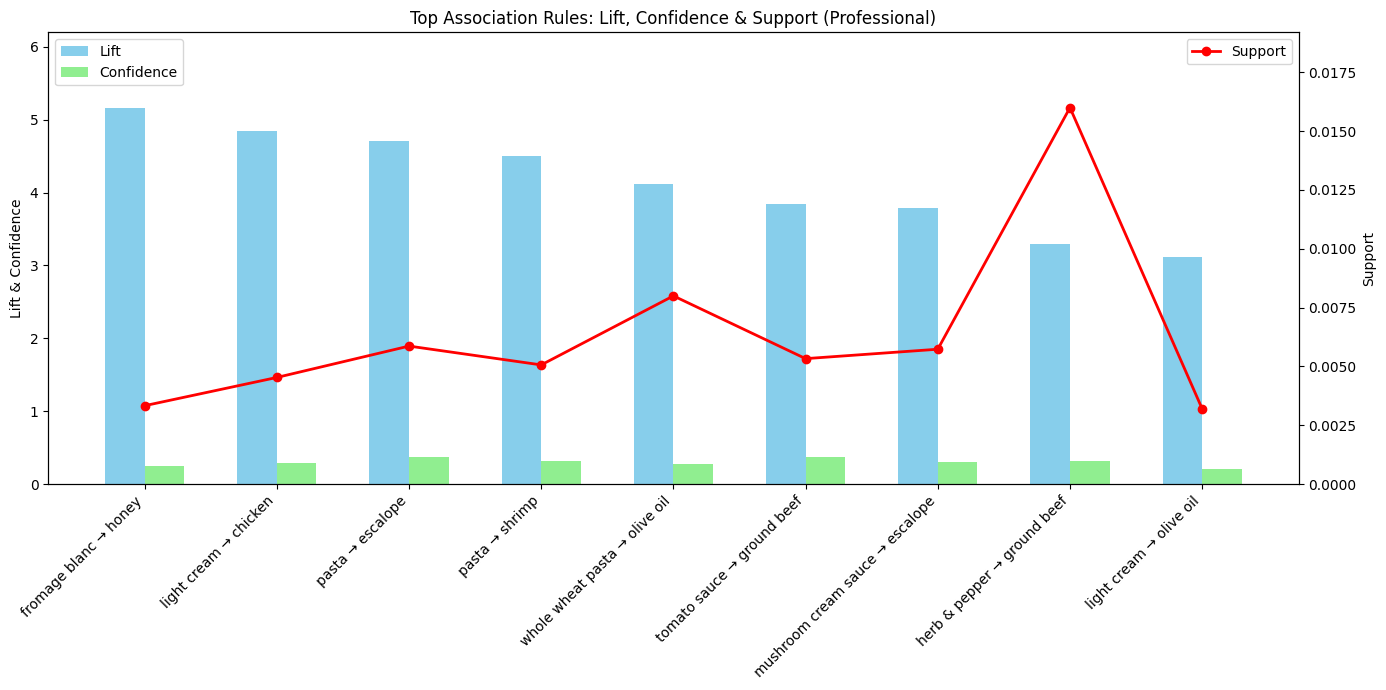

In [90]:
# Select top rules by Lift (up to 10)
top_rules = resultsinDataFrame.nlargest(n=10, columns='Lift')
num_rules = len(top_rules)
indices = np.arange(num_rules)
bar_width = 0.3

# Create figure
fig, ax1 = plt.subplots(figsize=(14,7))

# Plot Lift and Confidence on primary y-axis
ax1.bar(indices - bar_width/2, top_rules['Lift'], width=bar_width, color='skyblue', label='Lift')
ax1.bar(indices + bar_width/2, top_rules['Confidence'], width=bar_width, color='lightgreen', label='Confidence')
ax1.set_ylabel('Lift & Confidence')
ax1.set_ylim(0, max(top_rules['Lift'].max(), top_rules['Confidence'].max())*1.2)

# Set x-axis labels
ax1.set_xticks(indices)
ax1.set_xticklabels([f"{lhs} → {rhs}" for lhs, rhs in zip(top_rules['Left Hand Side'], top_rules['Right Hand Side'])], rotation=45, ha='right')

# Plot Support on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(indices, top_rules['Support'], color='red', marker='o', linewidth=2, label='Support')
ax2.set_ylabel('Support')
ax2.set_ylim(0, max(top_rules['Support'].max()*1.2, 0.01))  # make sure small supports are visible

# Add title and legend
plt.title('Top Association Rules: Lift, Confidence & Support (Professional)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()